In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from simulator import simulate
from scipy.stats import multivariate_normal

In [2]:
def compute_summary(I, R, H):
    eps = 1e-6

    # --- Infection ---

    t = np.arange(len(I))

    # 1) EARLY GROWTH RATE
    t_early = t[:min(20, len(I))]
    slope = np.polyfit(t_early, np.log(I[:len(t_early)] + eps), 1)[0]

    # 2) NORMALISED INFECTION PEAK
    peak_I = np.max(I)
    peak_norm_I = peak_I / (np.mean(I[:10]) + eps)

    # 3) TIME TO PEAK
    t_peak = np.argmax(I)

    # 4) TOTAL BURDEN
    auc_I = np.sum(I)

    # 5) DECAY RATE AFTER PEAK
    if t_peak < len(I) - 5:
        t_decay = t[t_peak:]
        I_decay = I[t_peak:]
        mask = I_decay > 0
        if np.sum(mask) > 5:
            decay_slope = np.polyfit(
                t_decay[mask],
                np.log(I_decay[mask] + eps),
                1
            )[0]
        else:
            decay_slope = 0.0
    else:
        decay_slope = 0.0

    # --- Rewiring ---

    total_R = np.sum(R)
    peak_R = np.max(R)

    # 6) REWIRING PER INFECTION
    rw_per_inf = total_R / (auc_I + eps)

    # 7) TOTAL REWIRING PEAK
    peak_rw_norm = peak_R / len(R)

    # 8) CORRELATION (I-R COUPLING)
    corr_IR = np.corrcoef(I, R)[0, 1] if np.std(R) > 0 else 0.0

    # --- Network ---

    degrees = np.arange(len(H))
    total_nodes = np.sum(H)

    # 9) NETWORK DEGREE MEAN
    mean_deg = np.dot(degrees, H) / total_nodes

    # 10) NETWORK DEGREE VARIANCE
    var_deg = np.dot(H, (degrees - mean_deg) ** 2) / total_nodes

    return np.array([
        slope,
        peak_norm_I,
        t_peak,
        auc_I,
        decay_slope,
        rw_per_inf,
        peak_rw_norm,
        corr_IR,
        mean_deg,
        var_deg
    ])

In [ ]:
infected_df = pd.read_csv("data\\infected_timeseries.csv")
rewire_df = pd.read_csv("data\\rewiring_timeseries.csv")
degree_df = pd.read_csv("data\\final_degree_histograms.csv")


def get_observed_summaries():
    summaries = []

    for rep_id in infected_df["replicate_id"].unique():
        I = infected_df[infected_df.replicate_id == rep_id]["infected_fraction"].values
        R = rewire_df[rewire_df.replicate_id == rep_id]["rewire_count"].values

        H_df = degree_df[degree_df.replicate_id == rep_id]
        H = np.zeros(31)
        for _, row in H_df.iterrows():
            H[int(row["degree"])] = row["count"]

        summaries.append(compute_summary(I, R, H))

    return np.array(summaries)


summaries_obs = get_observed_summaries()
S_obs = np.mean(summaries_obs, axis=0)

scale = np.std(summaries_obs, axis=0) + 1e-6

In [4]:
def compute_distance(S_sim, S_obs, scale):
    return np.linalg.norm((S_sim - S_obs) / scale)

In [5]:
def sample_prior(rng):
    return np.array([
        rng.uniform(0.05, 0.5),
        rng.uniform(0.02, 0.2),
        rng.uniform(0.0, 0.8)
    ])

def prior_pdf(theta):
    beta, gamma, rho = theta
    if not (0.05 <= beta <= 0.5):
        return 0.0
    if not (0.02 <= gamma <= 0.2):
        return 0.0
    if not (0.0 <= rho <= 0.8):
        return 0.0
    return 1.0

def kernel_pdf(theta_new, theta_old, cov):
    return multivariate_normal.pdf(theta_new, mean=theta_old, cov=cov)

In [6]:
def simulate_summary(theta, rng, n_sim=5):
    summaries = []
    for _ in range(n_sim):
        I, R, H = simulate(*theta, rng=rng)
        summaries.append(compute_summary(I, R, H))
    return np.mean(summaries, axis=0)

In [7]:
def systematic_resample(weights, rng):
    N = len(weights)
    positions = (rng.random() + np.arange(N)) / N
    cumsum = np.cumsum(weights)

    indexes = np.zeros(N, dtype=int)
    i = j = 0

    while i < N:
        if positions[i] < cumsum[j]:
            indexes[i] = j
            i += 1
        else:
            j += 1

    return indexes

In [ ]:
def smc_abc(
    S_obs,
    scale,
    N_particles=1000,
    T=5,
    alpha=0.2,
    n_sim=5,
    pool_factor=5,
    batch_size=200,
    rng_seed=3247,
    cov_reg=1e-6
):
    rng = np.random.default_rng(rng_seed)
    dim = 3

    particles = np.array([sample_prior(rng) for _ in range(N_particles)])
    weights = np.ones(N_particles) / N_particles

    epsilons = []

    for t in range(T):
        print(f"\n--- Iteration {t+1} ---")

        # -------------------------------
        # Adaptive kernel
        # -------------------------------
        if t == 0:
            cov = np.eye(dim)
        else:
            cov = 2.0 * np.cov(particles.T)
            cov += cov_reg * np.eye(dim)

        particles_prev = particles.copy()
        weights_prev = weights.copy()

        # -------------------------------
        # Candidate pool
        # -------------------------------
        target_pool = pool_factor * N_particles

        pool_particles = []
        pool_distances = []

        while len(pool_particles) < target_pool:

            batch = min(batch_size, target_pool - len(pool_particles))

            if t == 0:
                thetas = np.array([sample_prior(rng) for _ in range(batch)])
            else:
                idx = rng.choice(N_particles, size=batch, p=weights)
                means = particles[idx]

                noise = rng.multivariate_normal(
                    mean=np.zeros(dim),
                    cov=cov,
                    size=batch
                )

                thetas = means + noise

                for i in range(batch):
                    while prior_pdf(thetas[i]) == 0:
                        thetas[i] = means[i] + rng.multivariate_normal(
                            mean=np.zeros(dim),
                            cov=cov
                        )

            sims = np.array([
                simulate_summary(theta, rng, n_sim=n_sim)
                for theta in thetas
            ])

            dists = np.array([
                compute_distance(sims[i], S_obs, scale)
                for i in range(len(thetas))
            ])

            pool_particles.extend(thetas)
            pool_distances.extend(dists)

        pool_particles = np.array(pool_particles)
        pool_distances = np.array(pool_distances)

        # -------------------------------
        # Finding epsilon
        # -------------------------------
        epsilon = np.quantile(pool_distances, alpha)
        epsilons.append(epsilon)

        print(f"Epsilon: {epsilon:.6f}")

        # -------------------------------
        # Selection step
        # -------------------------------
        accepted_idx = np.where(pool_distances <= epsilon)[0]

        if len(accepted_idx) > N_particles:
            accepted_idx = rng.choice(accepted_idx, N_particles, replace=False)

        particles = pool_particles[accepted_idx]

        # -------------------------------
        # Weight update step
        # -------------------------------
        if t == 0:
            weights = np.ones(len(particles)) / len(particles)

        else:
            new_weights = np.zeros(len(particles))

            for i in range(len(particles)):

                num = prior_pdf(particles[i])

                kernel_vals = np.array([
                    kernel_pdf(particles[i], particles_prev[j], cov)
                    for j in range(N_particles)
                ])

                denom = np.sum(weights_prev * kernel_vals)

                new_weights[i] = num / (denom + 1e-12)

            weights = new_weights / np.sum(new_weights)

        # -------------------------------
        # ESS + Resampling step
        # -------------------------------
        ess = 1.0 / np.sum(weights ** 2)
        print(f"ESS: {ess:.2f}")

        if ess < 0.5 * N_particles:
            idx = systematic_resample(weights, rng)
            particles = particles[idx]
            weights = np.ones(N_particles) / N_particles

            # rejuvenation step
            cov = 2.0 * np.cov(particles.T) + cov_reg * np.eye(dim)

            noise = rng.multivariate_normal(
                mean=np.zeros(dim),
                cov=cov,
                size=N_particles
            )

            particles += noise
    print()
    print("Algorithm complete")

    return particles, weights, epsilons

In [9]:
particles, weights, eps = smc_abc(S_obs, scale)


--- Iteration 1 ---
Epsilon: 11.358710
ESS: 1000.00

--- Iteration 2 ---
Epsilon: 8.630566
ESS: 972.05

--- Iteration 3 ---
Epsilon: 7.193844
ESS: 972.38

--- Iteration 4 ---
Epsilon: 5.912369
ESS: 968.75

--- Iteration 5 ---
Epsilon: 4.821944
ESS: 970.30

Algorithm complete


In [10]:
def weighted_quantile(values, quantiles, weight):
    values = np.array(values)
    quantiles = np.array(quantiles)
    weight = np.array(weight)

    sorter = np.argsort(values)
    values = values[sorter]
    weight = weight[sorter]

    cdf = np.cumsum(weight)
    cdf /= cdf[-1]

    return np.interp(quantiles, cdf, values)

In [11]:
for i, name in enumerate(["β", "γ", "ρ"]):
    data = particles[:, i]
    mean = np.average(data, weights=weights)
    lower, upper = weighted_quantile(
        data,
        [0.025, 0.975],
        weights
    )
    print(f"{name}:")
    print(f"Posterior Mean = {mean:.4f}")
    print(f"95% credible interval = ({lower:.4f}, {upper:.4f})")
    print()

β:
Posterior Mean = 0.1746
95% credible interval = (0.1159, 0.2397)

γ:
Posterior Mean = 0.0837
95% credible interval = (0.0662, 0.1033)

ρ:
Posterior Mean = 0.3077
95% credible interval = (0.2105, 0.4107)



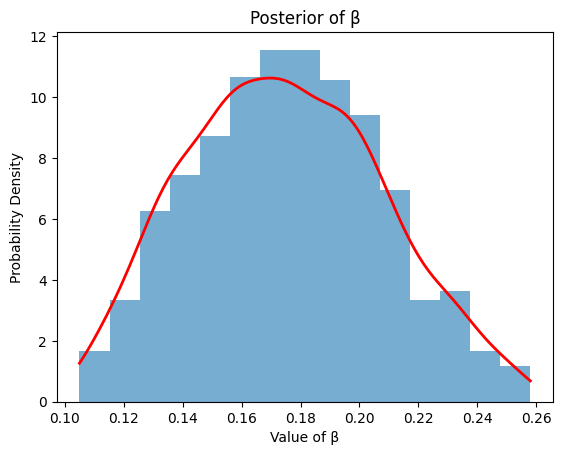

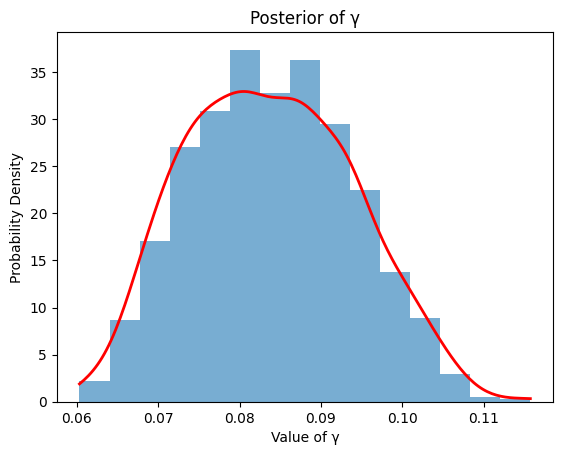

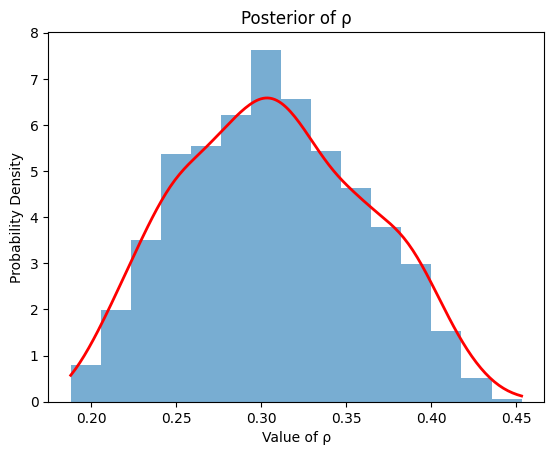

In [12]:
from scipy.stats import gaussian_kde

for i, name in enumerate(["β", "γ", "ρ"]):
    data = particles[:, i]
    plt.hist(data, bins=15, density=True, alpha=0.6)

    kde = gaussian_kde(data, weights=weights)
    xs = np.linspace(data.min(), data.max(), 200)
    plt.xlabel(f"Value of {name}")
    plt.ylabel("Probability Density")
    plt.plot(xs, kde(xs), 'r-', linewidth=2)
    plt.title(f"Posterior of {name}")
    plt.show()

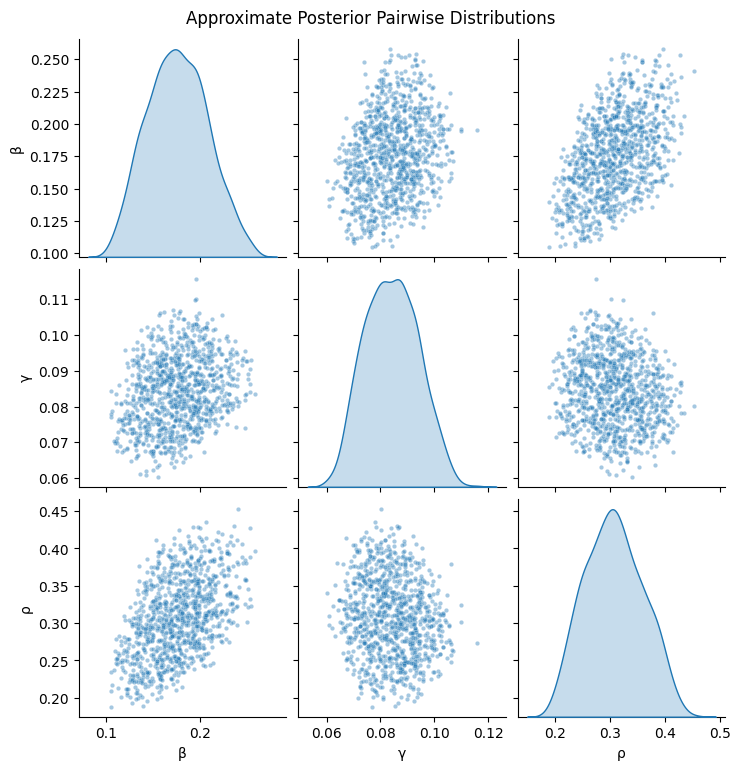

In [13]:
import seaborn as sns

df_post = pd.DataFrame(particles, columns=["β", "γ", "ρ"])

sns.pairplot(
    df_post,
    diag_kind="kde",
    plot_kws={"s": 10, "alpha": 0.4}
)

plt.suptitle("Approximate Posterior Pairwise Distributions", y=1.02)
plt.show()

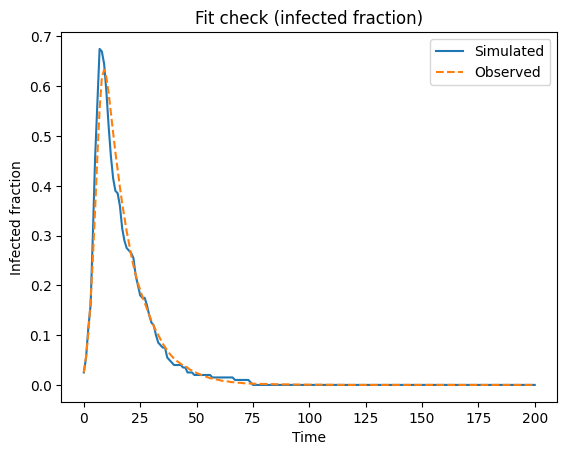

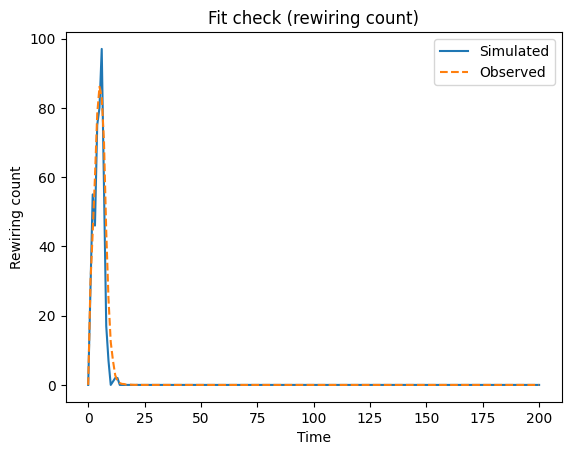

In [14]:
# Sanity check

theta_mean = np.average(particles, axis=0, weights=weights)

I_sim, R_sim, H_sim = simulate(*theta_mean)

I_obs = infected_df.groupby("time")["infected_fraction"].mean().values

plt.plot(I_sim, label="Simulated")
plt.plot(I_obs, label="Observed", linestyle="--")

plt.title("Fit check (infected fraction)")
plt.xlabel("Time")
plt.ylabel("Infected fraction")
plt.legend()
plt.show()

R_obs = rewire_df.groupby("time")["rewire_count"].mean().values

t = np.arange(min(len(R_sim), len(R_obs)))

plt.plot(t, R_sim[:len(t)], label="Simulated")
plt.plot(t, R_obs[:len(t)], label="Observed", linestyle="--")

plt.title("Fit check (rewiring count)")
plt.xlabel("Time")
plt.ylabel("Rewiring count")
plt.legend()
plt.show()